In [6]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Load the dataset
cfpb_df = pd.read_csv("cfpb_march14.csv")
cfpb_df

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,01/06/20,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"According to Federal Law, XXXX is legal. I opened an online business. I used Square as my vehicle of payment. After 2 sales totaling {$950.00}, they deactivated my account saying it was a high ris...",NaN,"Block, Inc.",FL,34683,Older American,Consent provided,Web,01/06/20,Closed with explanation,Yes,NaN,3486993
1,10/04/18,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Fraud or scam,NaN,I was a victim of a fake Cashiers Check scam. My bank ( Fifth Third ) failed to identify a fraudulent cashiers check I was given by a potential car buyer from craigslist. I cashed the check and re...,NaN,FIFTH THIRD FINANCIAL CORPORATION,IN,46220,NaN,Consent provided,Web,10/04/18,Closed with explanation,Yes,NaN,3037645
2,04/27/21,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,"On XX/XX/2021, my husband received an email from XXXX indicating that his account had been compromised and asked that he call a given telephone number for assistance. My husband called the telepho...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"BANK OF AMERICA, NATIONAL ASSOCIATION",PA,19355,Older American,Consent provided,Web,04/27/21,Closed with explanation,Yes,NaN,4329943
3,03/18/20,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Fraud or scam,NaN,My identity was stolen I check my credit report and seen were someone open credit cards and and line of credits in using my name the year XXXX my wallet was stolen out of car I'm a victim of ident...,NaN,"John C. Heath, Attorney at Law, PLLC",LA,70114,NaN,Consent provided,Web,03/18/20,Closed with explanation,Yes,NaN,3570414
4,01/31/24,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"Hi there. \n\nIn XXXX of last year, a former friend I helped start their business with committed credit card fraud and was able to make a chargeback through PayPal two months after paying me. Thei...",NaN,"Paypal Holdings, Inc",CA,92651,NaN,Consent provided,Web,01/31/24,Closed with non-monetary relief,Yes,NaN,8249107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25848,03/29/24,"Money transfer, virtual currency, or money service",Virtual currency,Fraud or scam,NaN,"Commencing on or about XX/XX/2023, I fell victim to several multi-layered scam operations run by XXXX XXXX which involved me making deposits for a total amount of XXXX USD from my Wells Fargo acco...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33596,Older American,Consent provided,Web,03/29/24,Closed with explanation,Yes,NaN,8656352
25849,01/17/25,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,Money was taken out my account multiple times and when XXXX reached out to talk to someone XXXX always received the computer version that never helped me get my money back nor spoke to a live oper...,NaN,"Block, Inc.",VA,238XX,NaN,Consent provided,Web,01/17/25,Closed with explanation,Yes,NaN,11670572
25850,02/02/23,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,I tried to purchase a puppy through a breeder whose website was cleared by XXXX and ran as an ad on XXXX. I was in contact with the owner and they did all of the routine steps in making sure every...,NaN,JPMORGAN CHASE & CO.,OH,45240,NaN,Consent provided,Web,02/02/23,Closed with explanation,Yes,NaN,6533139
25851,07/29/

In [30]:
# Show data types for each variable
print(cfpb_df.dtypes)

Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                       float64
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Consumer consent provided?       object
Submitted via                    object
Date sent to company             object
Company response to consumer     object
Timely response?                 object
Consumer disputed?               object
Complaint ID                      int64
dtype: object


In [33]:
#Change date received variable to a date-time datatype
cfpb_df['Date received'] = pd.to_datetime(cfpb_df['Date received'], format='%m/%d/%y', errors='coerce')
print(cfpb_df.dtypes)
cfpb_df.head(5)

Date received                   datetime64[ns]
Product                                 object
Sub-product                             object
Issue                                   object
Sub-issue                              float64
Consumer complaint narrative            object
Company public response                 object
Company                                 object
State                                   object
ZIP code                                object
Tags                                    object
Consumer consent provided?              object
Submitted via                           object
Date sent to company                    object
Company response to consumer            object
Timely response?                        object
Consumer disputed?                      object
Complaint ID                             int64
dtype: object


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-01-06,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"According to Federal Law, XXXX is legal. I opened an online business. I used Square as my vehicle of payment. After 2 sales totaling {$950.00}, they deactivated my account saying it was a high ris...",NaN,"Block, Inc.",FL,34683,Older American,Consent provided,Web,01/06/20,Closed with explanation,Yes,NaN,3486993
1,2018-10-04,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Fraud or scam,NaN,I was a victim of a fake Cashiers Check scam. My bank ( Fifth Third ) failed to identify a fraudulent cashiers check I was given by a potential car buyer from craigslist. I cashed the check and re...,NaN,FIFTH THIRD FINANCIAL CORPORATION,IN,46220,NaN,Consent provided,Web,10/04/18,Closed with explanation,Yes,NaN,3037645
2,2021-04-27,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,"On XX/XX/2021, my husband received an email from XXXX indicating that his account had been compromised and asked that he call a given telephone number for assistance. My husband called the telepho...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"BANK OF AMERICA, NATIONAL ASSOCIATION",PA,19355,Older American,Consent provided,Web,04/27/21,Closed with explanation,Yes,NaN,4329943
3,2020-03-18,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Fraud or scam,NaN,My identity was stolen I check my credit report and seen were someone open credit cards and and line of credits in using my name the year XXXX my wallet was stolen out of car I'm a victim of ident...,NaN,"John C. Heath, Attorney at Law, PLLC",LA,70114,NaN,Consent provided,Web,03/18/20,Closed with explanation,Yes,NaN,3570414
4,2024-01-31,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"Hi there. \n\nIn XXXX of last year, a former friend I helped start their business with committed credit card fraud and was able to make a chargeback through PayPal two months after paying me. Thei...",NaN,"Paypal Holdings, Inc",CA,92651,NaN,Consent provided,Web,01/31/24,Closed with non-monetary relief,Yes,NaN,8249107


In [35]:
# Count the unique values for Product
cfpb_df['Product'].value_counts()

Product
Money transfer, virtual currency, or money service                              23906
Credit reporting, credit repair services, or other personal consumer reports      998
Money transfers                                                                   508
Prepaid card                                                                      310
Other financial service                                                           126
Virtual currency                                                                    5
Name: count, dtype: int64

In [36]:
# Count the unique values for Sub-product
cfpb_df['Sub-product'].value_counts()

Sub-product
Mobile or digital wallet                            8744
Domestic (US) money transfer                        8025
Virtual currency                                    4038
International money transfer                        1751
Credit repair services                               998
Check cashing service                                556
Foreign currency exchange                            341
Money order, traveler's check or cashier's check     322
Debt settlement                                      248
Traveler's check or cashier's check                  211
Refund anticipation check                            139
Money order                                          125
General purpose card                                 122
Payroll card                                          53
Gift or merchant card                                 52
ID prepaid card                                       24
Check cashing                                         21
Mobile wallet      

In [37]:
# Count the unique values for Company public response
cfpb_df['Company public response'].value_counts()

Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response                            6413
Company believes it acted appropriately as authorized by contract or law                                                    665
Company believes complaint caused principally by actions of third party outside the control or direction of the company      86
Company believes the complaint is the result of a misunderstanding                                                           51
Company chooses not to provide a public response                                                                             48
Company believes complaint is the result of an isolated error                                                                32
Company disputes the facts presented in the complaint                                                                        31
Company believes complaint represents an opportunity for improvement to better s

In [56]:
# Count the unique values for Company public response
cfpb_df['Sub-issue'].value_counts()

Series([], Name: count, dtype: int64)

In [57]:
# Count the unique values for Company public response
cfpb_df['State'].value_counts()

State
CA    3938
TX    2246
FL    2191
NY    1978
GA    1234
      ... 
MP       3
GU       3
AS       1
MH       1
AA       1
Name: count, Length: 61, dtype: int64

In [39]:
# Count the unique values for Company public response
cfpb_df['Company'].value_counts()

Company
Block, Inc.                              3338
Paypal Holdings, Inc                     3121
JPMORGAN CHASE & CO.                     2453
WELLS FARGO & COMPANY                    2318
BANK OF AMERICA, NATIONAL ASSOCIATION    2066
                                         ... 
LendingUSA                                  1
Pioneer Law Firm, P.C.                      1
Zeller & Associates, LLC                    1
Revco Management, LLC                       1
LAKEVIEW LOAN SERVICING, LLC                1
Name: count, Length: 756, dtype: int64

In [42]:
# Count the unique number of companies in the 'Company' column
unique_companies_count = cfpb_df['Company'].nunique()
unique_companies_count

756

In [93]:
# Get the count of each company
company_counts = cfpb_df['Company'].value_counts()

# Filter for companies that appear more than 100 times
over50reports_companies = company_counts[company_counts > 49].index

# Print the result (shows the company name and its count)
print(over50reports_companies)

Index(['Block, Inc.', 'Paypal Holdings, Inc', 'JPMORGAN CHASE & CO.',
       'WELLS FARGO & COMPANY', 'BANK OF AMERICA, NATIONAL ASSOCIATION',
       'Early Warning Services, LLC', 'Coinbase, Inc.', 'Chime Financial Inc',
       'CITIBANK, N.A.', 'WESTERN UNION COMPANY, THE', 'PNC Bank N.A.',
       'MONEYGRAM PAYMENT SYSTEMS WORLDWIDE INC',
       'CAPITAL ONE FINANCIAL CORPORATION', 'U.S. BANCORP', 'Foris DAX, Inc.',
       'NAVY FEDERAL CREDIT UNION', 'ROBINHOOD MARKETS INC.',
       'UNITED SERVICES AUTOMOBILE ASSOCIATION',
       'TRUIST FINANCIAL CORPORATION', 'TD BANK US HOLDING COMPANY',
       'TransferWise Ltd', 'John C. Heath, Attorney at Law, PLLC',
       'Winklevoss Exchange LLC', 'Experian Information Solutions Inc.',
       'SYNCHRONY FINANCIAL', 'Remitly, Inc.',
       'Payward Ventures Inc. dba Kraken', 'BAM Management US Holdings Inc.',
       'Empowerment Ventures, LLC', 'DISCOVER BANK',
       'FIFTH THIRD FINANCIAL CORPORATION', 'CITIZENS FINANCIAL GROUP, INC.',
 

Text(0, 0.5, 'Number of Companies')

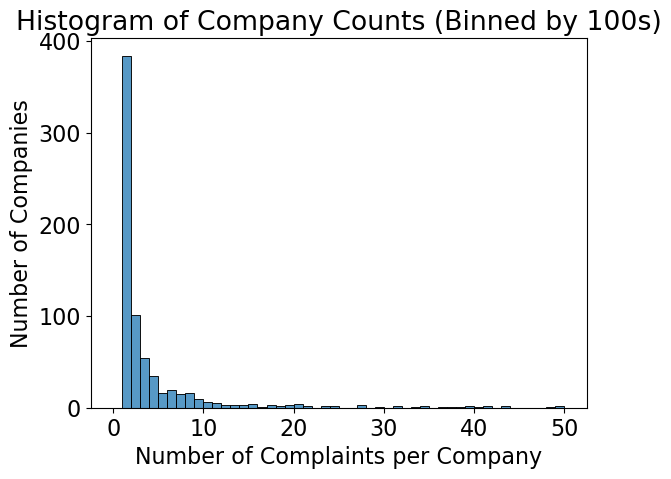

In [51]:
#histogram of company counts
sns.histplot(company_counts, binwidth=1, binrange=(0,50))

# 4. Add labels and a title
plt.title('Histogram of Company Counts (Binned by 100s)')
plt.xlabel('Number of Complaints per Company')
plt.ylabel('Number of Companies')

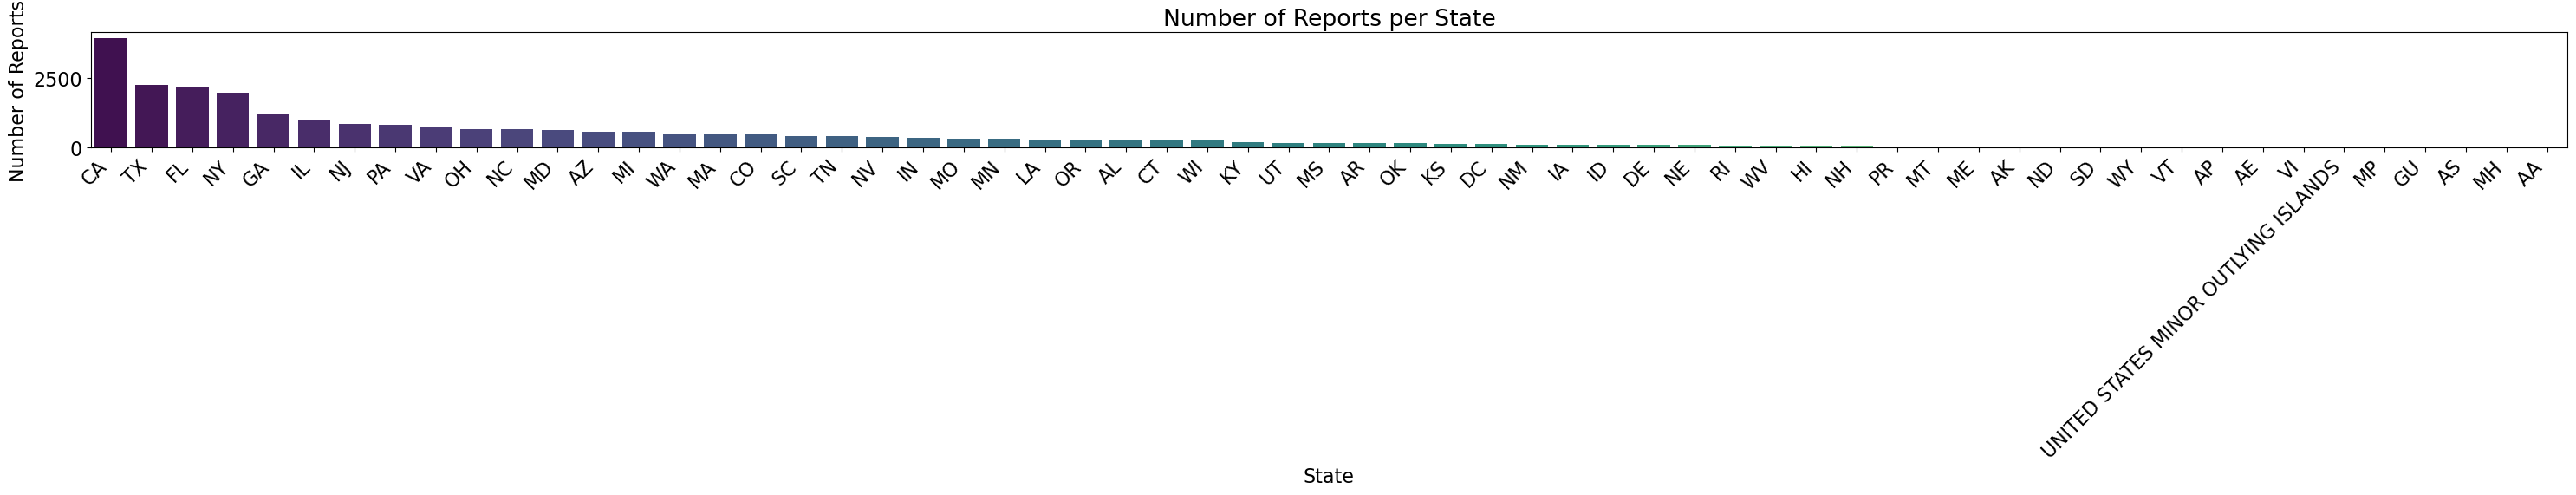

In [65]:
# Create a bar chart of number of reports by state
# Get the count of reports per state
state_counts = cfpb_df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Number of Reports']

# Ensure the bars are in sorted order (descending by number of reports)
state_counts = state_counts.sort_values(by='Number of Reports', ascending=False)

# 4. Create the bar chart
plt.figure(figsize=(30, 6))

ax = sns.barplot(
    data=state_counts, 
    x='State', 
    y='Number of Reports', 
    hue='State', 
    palette='viridis', 
    dodge=False
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# 5. Add labels and title
plt.title('Number of Reports per State')
plt.xlabel('State')
plt.ylabel('Number of Reports')

# 6. Rotate x-axis labels to prevent truncation/overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [68]:
# count reports by year script
cfpb_df['Year'] = cfpb_df['Date received'].dt.year.astype(int)
cfpb_df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,Year
0,2020-01-06,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"According to Federal Law, XXXX is legal. I opened an online business. I used Square as my vehicle of payment. After 2 sales totaling {$950.00}, they deactivated my account saying it was a high ris...",NaN,"Block, Inc.",FL,34683,Older American,Consent provided,Web,01/06/20,Closed with explanation,Yes,NaN,3486993,2020
1,2018-10-04,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Fraud or scam,NaN,I was a victim of a fake Cashiers Check scam. My bank ( Fifth Third ) failed to identify a fraudulent cashiers check I was given by a potential car buyer from craigslist. I cashed the check and re...,NaN,FIFTH THIRD FINANCIAL CORPORATION,IN,46220,NaN,Consent provided,Web,10/04/18,Closed with explanation,Yes,NaN,3037645,2018
2,2021-04-27,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,"On XX/XX/2021, my husband received an email from XXXX indicating that his account had been compromised and asked that he call a given telephone number for assistance. My husband called the telepho...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"BANK OF AMERICA, NATIONAL ASSOCIATION",PA,19355,Older American,Consent provided,Web,04/27/21,Closed with explanation,Yes,NaN,4329943,2021
3,2020-03-18,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Fraud or scam,NaN,My identity was stolen I check my credit report and seen were someone open credit cards and and line of credits in using my name the year XXXX my wallet was stolen out of car I'm a victim of ident...,NaN,"John C. Heath, Attorney at Law, PLLC",LA,70114,NaN,Consent provided,Web,03/18/20,Closed with explanation,Yes,NaN,3570414,2020
4,2024-01-31,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"Hi there. \n\nIn XXXX of last year, a former friend I helped start their business with committed credit card fraud and was able to make a chargeback through PayPal two months after paying me. Thei...",NaN,"Paypal Holdings, Inc",CA,92651,NaN,Consent provided,Web,01/31/24,Closed with non-monetary relief,Yes,NaN,8249107,2024


In [79]:
# Count the unique values for Year
cfpb_df['Year'].value_counts().sort_index()

Year
2015     408
2016     377
2017     630
2018     969
2019    1258
2020    1573
2021    2613
2022    3792
2023    3514
2024    3636
2025    6878
2026     205
Name: count, dtype: int64

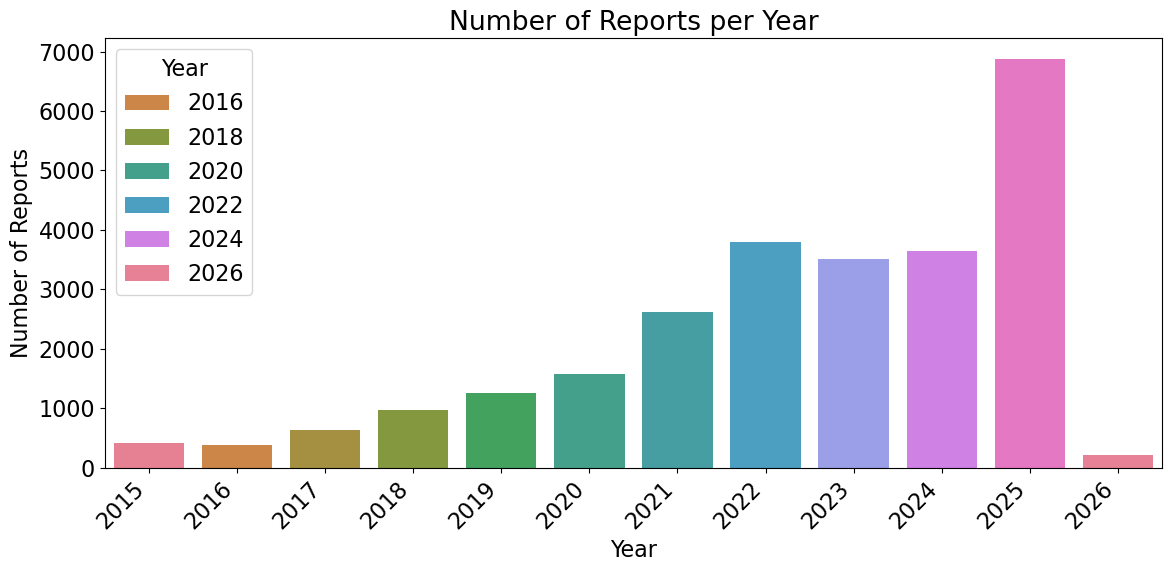

In [74]:
# Create a bar chart of number of reports by year
# Get the count of reports per state
year_counts = cfpb_df['Year'].value_counts().reset_index()
year_counts.columns = ['Year', 'Number of Reports']

# Ensure the bars are in sorted order (descending by number of reports)
year_counts = year_counts.sort_values(by='Year', ascending=True)

# 4. Create the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=year_counts, 
    x='Year', 
    y='Number of Reports', 
    hue='Year', 
    palette='husl', 
    dodge=False)

# 5. Add labels and title
plt.title('Number of Reports per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reports')

# 6. Rotate x-axis labels to prevent truncation/overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [81]:
over50reports_companies

Company
Block, Inc.                                3338
Paypal Holdings, Inc                       3121
JPMORGAN CHASE & CO.                       2453
WELLS FARGO & COMPANY                      2318
BANK OF AMERICA, NATIONAL ASSOCIATION      2066
Early Warning Services, LLC                1820
Coinbase, Inc.                             1460
Chime Financial Inc                         614
CITIBANK, N.A.                              455
WESTERN UNION COMPANY, THE                  363
PNC Bank N.A.                               360
MONEYGRAM PAYMENT SYSTEMS WORLDWIDE INC     329
CAPITAL ONE FINANCIAL CORPORATION           302
U.S. BANCORP                                288
Foris DAX, Inc.                             278
NAVY FEDERAL CREDIT UNION                   267
ROBINHOOD MARKETS INC.                      251
UNITED SERVICES AUTOMOBILE ASSOCIATION      245
TRUIST FINANCIAL CORPORATION                236
TD BANK US HOLDING COMPANY                  220
TransferWise Ltd                

In [ ]:
# 3. Group the data by 'Year' and 'Company', and calculate the size (Number of Reports)
reports_by_year_company = cfpb_df.groupby(['Year', 'Company']).size().reset_index(name='Number of Reports')

# 4. Sort the dataset by Year (Ascending), Company (Ascending), and Number of Reports (Descending)
sorted_reports = reports_by_year_company.sort_values(
    by=['Year', 'Company', 'Number of Reports'], 
    ascending=[True, True, False]
)

# 5. Save the final sorted table to a new CSV file
output_filename = 'reports_sorted_by_year_company.csv'
sorted_reports.to_csv(output_filename, index=False)

# Display the top 15 rows of the sorted data
print(sorted_reports.head(15))

In [ ]:
#Identify area name with largest frequency of night crimes

* Take in Company column, select night hours (10pm - 3:59pm), sort by highest frequency of crime

In [83]:
# Filter Companies that have more than one report
has_multiple_reports = company_counts[company_counts > 1]
print(has_multiple_reports)

Company
Block, Inc.                              3338
Paypal Holdings, Inc                     3121
JPMORGAN CHASE & CO.                     2453
WELLS FARGO & COMPANY                    2318
BANK OF AMERICA, NATIONAL ASSOCIATION    2066
                                         ... 
Social Finance, Inc.                        2
BANKUNITED, NATIONAL ASSOCIATION            2
Sunbit, Inc.                                2
Young America Holdings, LLC                 2
Midwest Recovery Systems                    2
Name: count, Length: 372, dtype: int64


In [94]:
#Filter the main dataset to only keep rows belonging to companies with more than 50 reports
over50_df = cfpb_df[cfpb_df['Company'].isin(over50reports_companies)]

# 5. Group the filtered data by 'Company' and 'Year', then count the size
year_comp50 = over50_df.groupby(['Company', 'Year']).size().reset_index(name='Number of Reports')

# 6. Sort for easier reading (Company alphabetically, then Year chronologically)
sorted_year_comp50 = year_comp50.sort_values(by=['Company', 'Year'])

# Output the results
print(sorted_year_comp50)

                     Company  Year  Number of Reports
0        ALLY FINANCIAL INC.  2018                  3
1        ALLY FINANCIAL INC.  2019                  2
2        ALLY FINANCIAL INC.  2020                  1
3        ALLY FINANCIAL INC.  2021                  3
4        ALLY FINANCIAL INC.  2022                 11
..                       ...   ...                ...
402  Winklevoss Exchange LLC  2021                 45
403  Winklevoss Exchange LLC  2022                 28
404  Winklevoss Exchange LLC  2023                 22
405  Winklevoss Exchange LLC  2024                 22
406  Winklevoss Exchange LLC  2025                 25

[407 rows x 3 columns]


In [97]:
# For each company with over 50 reports, display year with least amount of reports, display year with most amount of reports, and display total amount of reports made in all years.
peak_year = over50_df.groupby('Company', as_index=False)['Year'].count().sort_values("Year", ascending=False).iloc[0]["Year"]

In [98]:
peak_year

np.int64(3338)

In [104]:
# 2. Get the total reports for each company
company_totals = cfpb_df.groupby('Company').size()

# 3. Filter for companies that have strictly > 50 reports total
target_companies = company_totals[company_totals > 50].index

# 4. Filter original dataframe to only include these specific companies
filtered_df = cfpb_df[cfpb_df['Company'].isin(target_companies)]

# 5. Group by Company and Year to get the counts per year
yearly_counts = filtered_df.groupby(['Company', 'Year']).size().reset_index(name='Count')

# 6. Extract the min year, max year, and total reports ALONG WITH their counts
results = []
for company in target_companies:
    # Get just the data for this specific company
    comp_data = yearly_counts[yearly_counts['Company'] == company]
    
    # Identify the index (row number) of the minimum and maximum counts
    min_idx = comp_data['Count'].idxmin()
    max_idx = comp_data['Count'].idxmax()
    
    # Extract the Year and the Count for the least reports
    min_year = comp_data.loc[min_idx, 'Year']
    min_count = comp_data.loc[min_idx, 'Count']
    
    # Extract the Year and the Count for the most reports
    max_year = comp_data.loc[max_idx, 'Year']
    max_count = comp_data.loc[max_idx, 'Count']
    
    # Calculate total reports
    total_reports = comp_data['Count'].sum()
    
    # Add to our final results list
    results.append({
        'Company': company,
        'low year': min_year,
        'low year report count': min_count,     
        'peak year': max_year,
        'peak year report count': max_count,     
        'total reports': total_reports
    })

# 7. Convert results to a neat dataframe and display
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                                Company  low year  low year report count  peak year  peak year report count  total reports
                    ALLY FINANCIAL INC.      2020                      1       2022                      11             51
               AMERICAN EXPRESS COMPANY      2020                      2       2016                      17             86
        BAM Management US Holdings Inc.      2020                      1       2021                      70            121
  BANK OF AMERICA, NATIONAL ASSOCIATION      2015                      9       2025                     411           2066
                            Block, Inc.      2026                     39       2025                    1909           3338
      CAPITAL ONE FINANCIAL CORPORATION      2015                      2       2025                      70            302
                         CITIBANK, N.A.      2015                      6       2024                      99            455
         CITIZEN

In [116]:
#Pivot the yearly counts so every year becomes its own column
pivot_years = yearly_counts.pivot(index='Company', columns='Year', values='Count')

# Fill missing years with 0 and convert them back to integers
pivot_years = pivot_years.fillna(0).astype(int)

# Add a total reports column
pivot_years['Total Sum'] = pivot_years.sum(axis=1)

# Display the final result
sorted_pivot_years = pivot_years.sort_values(by='Total Sum', ascending=False)

sorted_pivot_years 

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,Total Sum
Company,,,,,,,,,,,,,
"Block, Inc.",0,0,0,0,77,201,173,223,351,365,1909,39,3338
"Paypal Holdings, Inc",47,60,84,117,266,327,308,350,378,439,719,26,3121
JPMORGAN CHASE & CO.,11,13,36,96,146,117,307,448,395,377,497,10,2453
WELLS FARGO & COMPANY,5,12,40,127,109,112,209,450,383,348,476,47,2318
"BANK OF AMERICA, NATIONAL ASSOCIATION",9,12,27,105,111,162,204,376,334,302,411,13,2066
"Early Warning Services, LLC",0,0,1,27,71,81,126,357,204,155,795,3,1820
"Coinbase, Inc.",4,1,112,128,24,68,311,245,164,183,218,2,1460
Chime Financial Inc,0,0,0,0,0,8,19,36,68,130,344,9,614
"CITIBANK, N.A.",6,11,13,22,21,26,49,69,59,99,74,6,455


In [ ]:
# Filter the dataset for coinbase, select year with most reports. Create a histogram of number of reports per month.

In [125]:
# Add word count variable to cfpb_df
cfpb_df['_word_count'] = cfpb_df['Consumer complaint narrative'].str.split().str.len()
cfpb_df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,Year,_word_count
0,2020-01-06,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"According to Federal Law, XXXX is legal. I opened an online business. I used Square as my vehicle of payment. After 2 sales totaling {$950.00}, they deactivated my account saying it was a high ris...",NaN,"Block, Inc.",FL,34683,Older American,Consent provided,Web,01/06/20,Closed with explanation,Yes,NaN,3486993,2020,312
1,2018-10-04,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Fraud or scam,NaN,I was a victim of a fake Cashiers Check scam. My bank ( Fifth Third ) failed to identify a fraudulent cashiers check I was given by a potential car buyer from craigslist. I cashed the check and re...,NaN,FIFTH THIRD FINANCIAL CORPORATION,IN,46220,NaN,Consent provided,Web,10/04/18,Closed with explanation,Yes,NaN,3037645,2018,171
2,2021-04-27,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,"On XX/XX/2021, my husband received an email from XXXX indicating that his account had been compromised and asked that he call a given telephone number for assistance. My husband called the telepho...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"BANK OF AMERICA, NATIONAL ASSOCIATION",PA,19355,Older American,Consent provided,Web,04/27/21,Closed with explanation,Yes,NaN,4329943,2021,956
3,2020-03-18,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Fraud or scam,NaN,My identity was stolen I check my credit report and seen were someone open credit cards and and line of credits in using my name the year XXXX my wallet was stolen out of car I'm a victim of ident...,NaN,"John C. Heath, Attorney at Law, PLLC",LA,70114,NaN,Consent provided,Web,03/18/20,Closed with explanation,Yes,NaN,3570414,2020,106
4,2024-01-31,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"Hi there. \n\nIn XXXX of last year, a former friend I helped start their business with committed credit card fraud and was able to make a chargeback through PayPal two months after paying me. Thei...",NaN,"Paypal Holdings, Inc",CA,92651,NaN,Consent provided,Web,01/31/24,Closed with non-monetary relief,Yes,NaN,8249107,2024,365


In [129]:
# Get summary statistics for word count

word_count_stats = cfpb2025_df['_word_count'].describe()
word_count_stats

count    6878.000000
mean      203.641320
std       243.387348
min         7.000000
25%        72.000000
50%       144.000000
75%       254.000000
max      5699.000000
Name: _word_count, dtype: float64

<Axes: ylabel='_word_count'>

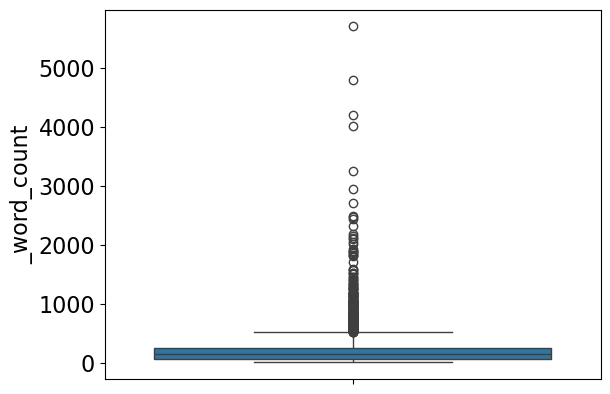

In [130]:
sns.boxplot(y=cfpb2025_df["_word_count"])

In [120]:
# Select sample of reports to start the coding process 
# Filter: year >= 2025
cfpb2025_df = cfpb_df[cfpb_df['Date received'].dt.year == 2025]
print(f'Rows with year 2025: {len(cfpb2025_df)}')

# Filter: narrative more than 300 words
cfpb2025_df = cfpb2025_df[cfpb2025_df['Consumer complaint narrative'].notna()]
cfpb2025_df = cfpb2025_df.copy()
cfpb2025_df['_word_count'] = cfpb2025_df['Consumer complaint narrative'].str.split().str.len()
cfpb2025_300w_df = cfpb2025_df[cfpb2025_df['_word_count'] >= 300]
print(f'Rows with 300 or more words: {len(cfpb2025_300w_df)}')

# Sample 10 reports and save as a seperate dataframe named cfpb_df_sample_10
if len(cfpb2025_300w_df) >= 10:
    cfpb_df_sample_10 = cfpb2025_300w_df.sample(n=10, random_state=42)
else:
    cfpb_df_sample_10 = cfpb2025_300w_df
    print(f'WARNING: Only {len(cfpb_df_sample_10)} rows match criteria, taking all')

# Keep helper columns and save
cfpb_df_sample_10.to_csv('cfpb_sample1.csv', index=False)
print(f'Saved {len(cfpb_df_sample_10)} rows to cfpb_sample1.csv')

cfpb_df_sample_10

Rows with year 2025: 6878
Rows with 300 or more words: 1289
Saved 10 rows to cfpb_sample1.csv


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,Year,_word_count
22401,2025-09-30,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,"Incident Summary I was defrauded of {$1000.00} by an individual impersonating a law-enforcement officer.\n\nDetails of the Incident XXXX XX/XX/year> at XXXX AM, I received a phone call from a man ...",NaN,"Early Warning Services, LLC",FL,33441,NaN,Consent provided,Web,09/30/25,Closed with explanation,Yes,NaN,16270662,2025,376
23873,2025-07-22,"Money transfer, virtual currency, or money service",Virtual currency,Fraud or scam,NaN,"XXXX reporting identity theft and Cash Apps failure to resolve it after more than 100 days of repeated attempts to get help. I never signed up for Cash App or requested a card, yet an account was ...",NaN,"Block, Inc.",CA,94014,NaN,Consent provided,Web,07/22/25,Closed with explanation,Yes,NaN,14798248,2025,387
9222,2025-07-28,"Money transfer, virtual currency, or money service",International money transfer,Fraud or scam,NaN,"In XXXX, I was the victim of wire fraud that could have been prevented had JPMorgan Chase Bank followed basic verification procedures. The transaction was related to the purchase of residential la...",NaN,JPMORGAN CHASE & CO.,TX,75204,NaN,Consent provided,Web,07/28/25,Closed with explanation,Yes,NaN,14935180,2025,540
1663,2025-03-07,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,I saw a XXXX post on a friend 's account offering to sell cars and equipment. It was posed as a favor he was doing for an XXXX uncle. The original post asked for a deposit to reserve a purchase un...,NaN,"Paypal Holdings, Inc",MI,48423,NaN,Consent provided,Web,03/07/25,Closed with explanation,Yes,NaN,12369598,2025,607
1383,2025-04-25,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"I believe the seller, XXXX XXXX ( and XXXX XXXX as a payment facilitator ) has not acted in good faith, and the merchant ( PayPal ) has not backed my rights as a consumer to a refund when using th...",NaN,"Paypal Holdings, Inc",IL,60048,NaN,Consent provided,Web,04/25/25,Closed with explanation,Yes,NaN,13173468,2025,533
2480,2025-02-28,"Money transfer, virtual currency, or money service",Check cashing service,Fraud or scam,NaN,XXXX XXXX Class Action XXXXXXXX XXXX XXXX XXXX XXXXXXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX \nUnites States District Court for the XXXX XXXX XXXX Texas XXXX XXXX Division Case No : XXXXXXXX XXXX XX...,NaN,Comerica,SC,29651,"Older American, Servicemember",Consent provided,Web,02/28/25,Closed with monetary relief,Yes,NaN,12243783,2025,1158
8892,2025-11-30,"Money transfer, virtual currency, or money service",Virtual currency,Fraud or scam,NaN,"Company : Block, Inc. ( Cash App ) Product : Mobile Wallet / Virtual Payments Issue : Fraud or scam ; unauthorized transactions ; financial loss ; failure to assist Dollar Amount Lost : Exceeds {$...",NaN,"Block, Inc.",TX,770XX,Servicemember,Consent provided,Web,11/30/25,Closed with explanation,Yes,NaN,17601400,2025,320
20914,2025-01-24,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"XXXX XXXX XXXX XXXX XXXXXXXX XXXX XXXX, FL XXXX Date : XX/XX/2025 Consumer Financial Protection Bureau ( CFPB ) XXXX XXXX XXXX XXXX XXXX, XXXX XXXX Subject : Formal Complaint Against Cash App ( Bl...",NaN,"Block, Inc.",FL,33579,NaN,Consent provided,Web,01/24/25,Closed with explanation,Yes,NaN,11756196,2025,897
14598,2025-02-21,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,"On XX/XX/year>, I participated in a XXXX interview for a remote appointment setter position with what I believed to be a legit